# TKH Energy Efficiency Project
## 01 - Explore

### Goal
The goal of this project is to predict building energy efficiency outcomes from architectural design features.

# No columns were dropped because all columns are relevant to the project

## Initial Cleaning Note
No irrelevant columns were dropped because all available columns are relevant building-design features or target variables used for analysis and modeling.

### Target Variables
- `heating_load` (Y1)
- `cooling_load` (Y2)

### Prediction Objective
The goal is to understand how building design features relate to heating and cooling load, and to prepare the dataset for regression modeling.

# Lets begin with 

## 1. Loading the Data
## 2. A Scope of the Dataset Overview
## 3. Some data Quality Checks
## 4. A look at Target Distributions (Y1, Y2)
## 5. Take a peak at Feature Relationships / Correlations
## 6. Lastly EDA Findings

In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load file
path_raw_1 = "../data/raw/ENB2012_data.xlsx"
path_raw_2 = "../data/ENB2012_data.xlsx"
if os.path.exists(path_raw_1):
    file_path = path_raw_1
elif os.path.exists(path_raw_2):
    file_path = path_raw_2
else:
    raise FileNotFoundError("Could not find ENB2012_data.xlsx in ../data/raw/ or ../data/")

df = pd.read_excel(file_path)

# Clean column names
df.columns = df.columns.astype(str).str.strip()

# Rename columns
rename_map = {
    "X1": "relative_compactness",
    "X2": "surface_area",
    "X3": "wall_area",
    "X4": "roof_area",
    "X5": "overall_height",
    "X6": "orientation",
    "X7": "glazing_area",
    "X8": "glazing_area_distribution",
    "Y1": "heating_load",
    "Y2": "cooling_load"
}

expected = ["X1","X2","X3","X4","X5","X6","X7","X8","Y1","Y2"]

if all(col in df.columns for col in expected):
    df = df.rename(columns=rename_map)
else:
    df = df.iloc[:, :10].copy()
    df.columns = list(rename_map.values())

# ----------------------------
# Load & Inspect Data
# ----------------------------
print("Dataset shape:", df.shape)
display(df.head())
print("\nData types:")
display(df.dtypes)
print("\nMissing values:")
display(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# ----------------------------
# Initial Cleaning
# ----------------------------

# Fix data types
df["orientation"] = df["orientation"].astype("category")
df["glazing_area_distribution"] = df["glazing_area_distribution"].astype("category")

# Handle missing values
# If any missing values exist, use median for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
if df[numeric_cols].isna().sum().sum() > 0:
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Check for obvious data-entry issues
print("\nChecking for invalid values...")

print("Negative values in numeric columns:")
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f"{col}: {neg_count}")

print("\nUnique values for categorical-coded columns:")
print("orientation:", df["orientation"].unique())
print("glazing_area_distribution:", df["glazing_area_distribution"].unique())

# Save cleaned version
os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/energy_clean.csv", index=False)

Dataset shape: (768, 10)


,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution,heating_load,cooling_load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28



Data types:


relative_compactness         float64
surface_area                 float64
wall_area                    float64
roof_area                    float64
overall_height               float64
orientation                    int64
glazing_area                 float64
glazing_area_distribution      int64
heating_load                 float64
cooling_load                 float64
dtype: object


Missing values:


relative_compactness         0
surface_area                 0
wall_area                    0
roof_area                    0
overall_height               0
orientation                  0
glazing_area                 0
glazing_area_distribution    0
heating_load                 0
cooling_load                 0
dtype: int64


Duplicate rows: 0

Checking for invalid values...
Negative values in numeric columns:

Unique values for categorical-coded columns:
orientation: [2, 3, 4, 5]
Categories (4, int64): [2, 3, 4, 5]
glazing_area_distribution: [0, 1, 2, 3, 4, 5]
Categories (6, int64): [0, 1, 2, 3, 4, 5]


In [13]:
df = df.rename(columns={
    "X1": "relative_compactness",
    "X2": "surface_area",
    "X3": "wall_area",
    "X4": "roof_area",
    "X5": "overall_height",
    "X6": "orientation",
    "X7": "glazing_area",
    "X8": "glazing_area_distribution",
    "Y1": "heating_load",
    "Y2": "cooling_load"
})

In [20]:
for col in numeric_cols:
    print(col, "negative values:", (df[col] < 0).sum())

print("orientation values:", df["orientation"].unique())
print("glazing_area_distribution values:", df["glazing_area_distribution"].unique())

relative_compactness negative values: 0
surface_area negative values: 0
wall_area negative values: 0
roof_area negative values: 0
overall_height negative values: 0
glazing_area negative values: 0
heating_load negative values: 0
cooling_load negative values: 0
orientation values: [2, 3, 4, 5]
Categories (4, int64): [2, 3, 4, 5]
glazing_area_distribution values: [0, 1, 2, 3, 4, 5]
Categories (6, int64): [0, 1, 2, 3, 4, 5]


In [14]:
df["orientation"] = df["orientation"].astype("category")
df["glazing_area_distribution"] = df["glazing_area_distribution"].astype("category")
df.dtypes

relative_compactness          float64
surface_area                  float64
wall_area                     float64
roof_area                     float64
overall_height                float64
orientation                  category
glazing_area                  float64
glazing_area_distribution    category
heating_load                  float64
cooling_load                  float64
dtype: object

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df.isna().sum()

## Multicollinearity Check
Pairs with absolute correlation above 0.8 are flagged as possible multicollinearity concerns.

In [21]:
high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) > 0.8:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], val))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["Feature 1", "Feature 2", "Correlation"])
high_corr_df

NameError: name 'corr' is not defined

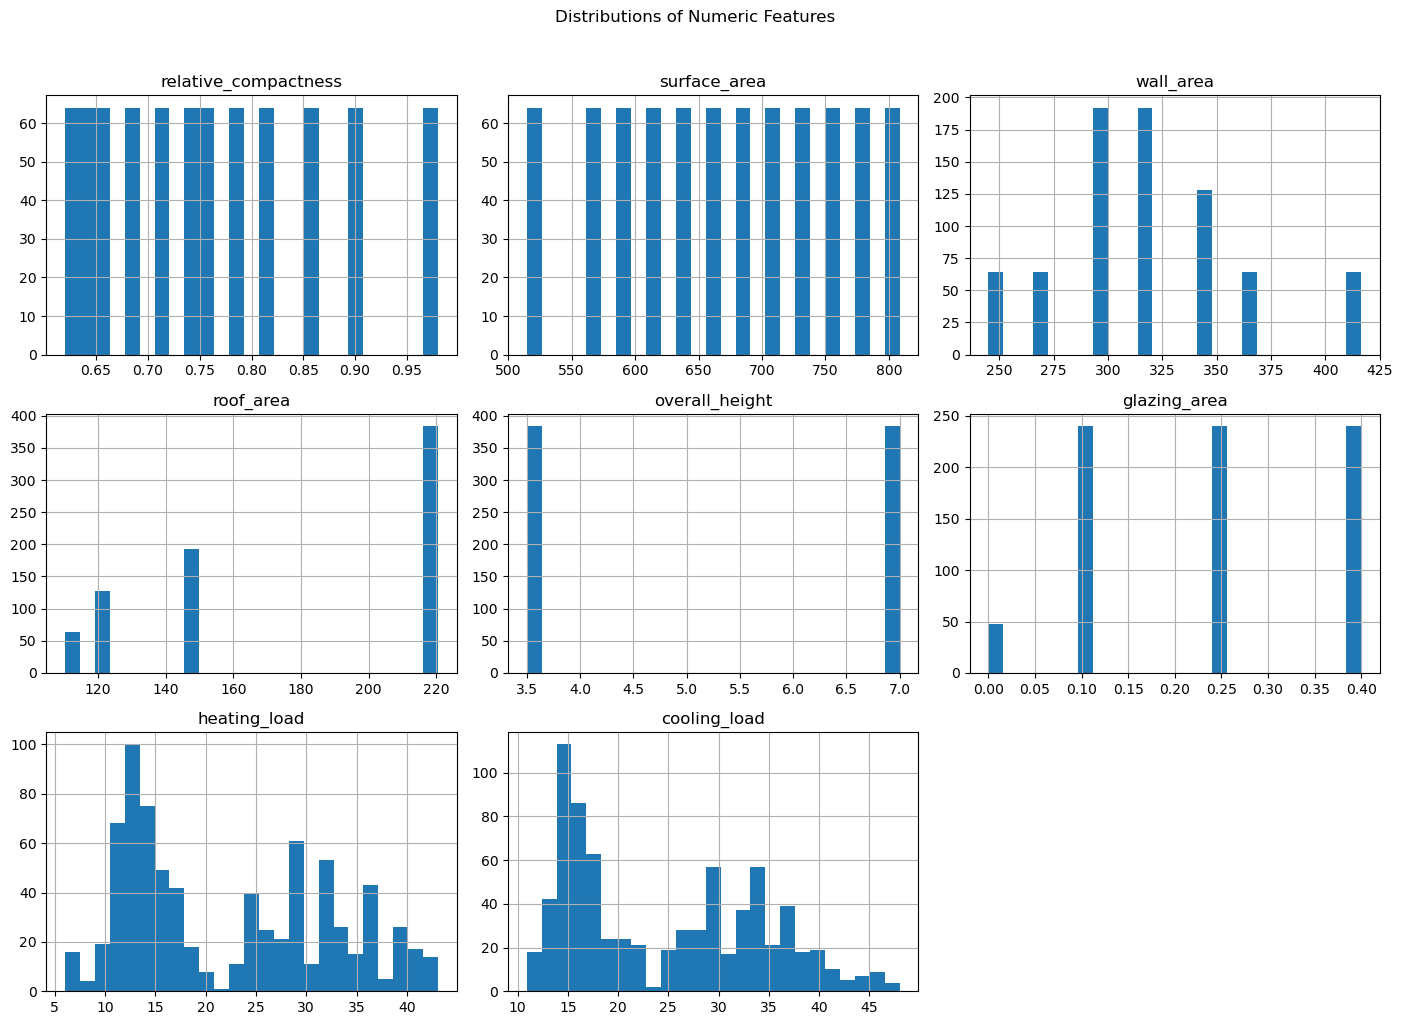

Skewness of numeric features:


,skewness
wall_area,0.533417
relative_compactness,0.495513
cooling_load,0.395992
heating_load,0.360446
overall_height,0.000000
glazing_area,-0.060254
surface_area,-0.125131
roof_area,-0.162764


In [10]:
# Histograms for all numeric columns
df[numeric_cols].hist(figsize=(14, 10), bins=25)
plt.suptitle("Distributions of Numeric Features", y=1.02)
plt.tight_layout()
plt.show()

# Skewness
skewness = df[numeric_cols].skew().sort_values(ascending=False)
print("Skewness of numeric features:")
display(skewness.to_frame("skewness"))

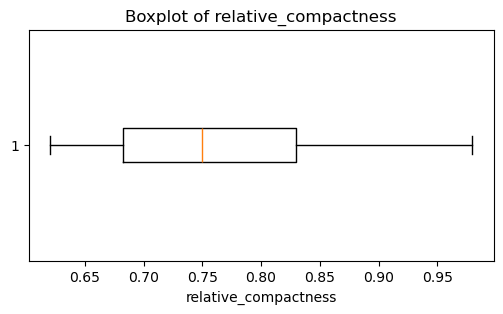

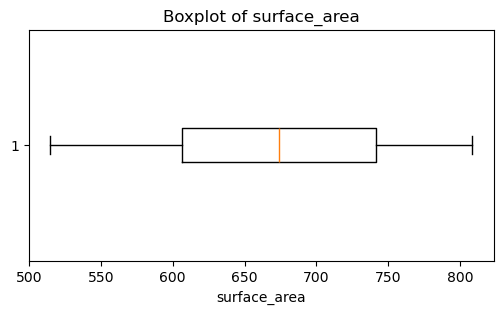

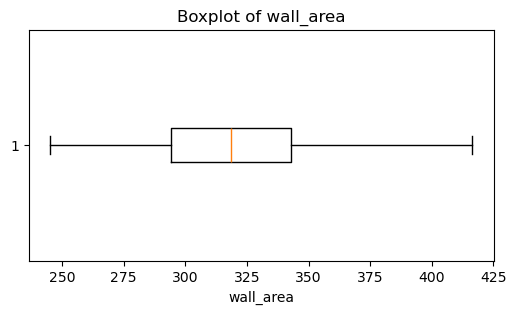

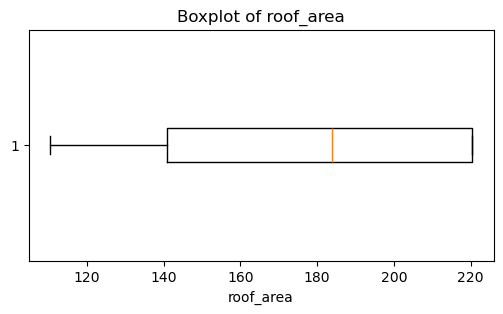

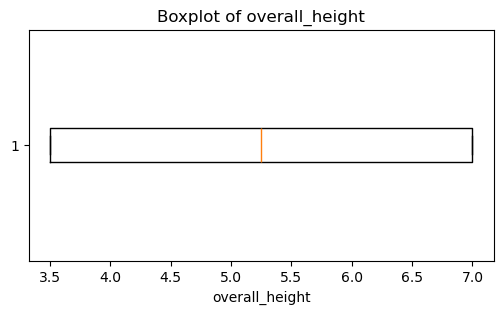

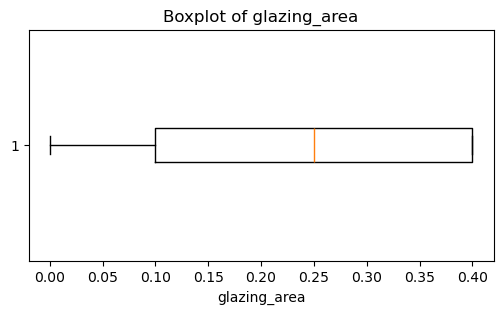

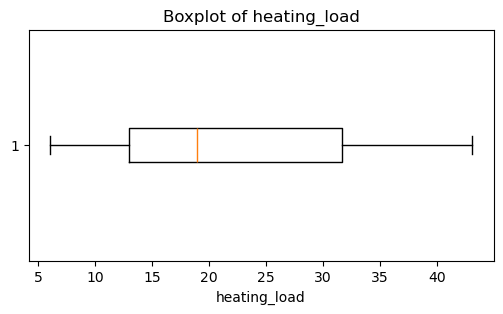

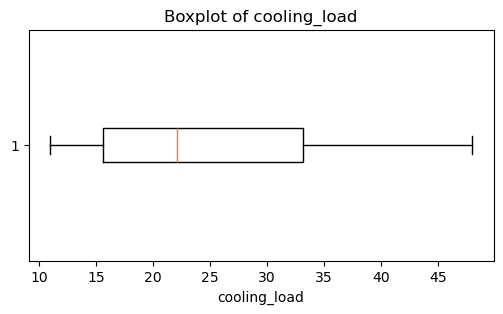

In [9]:
# Boxplots for numeric columns
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

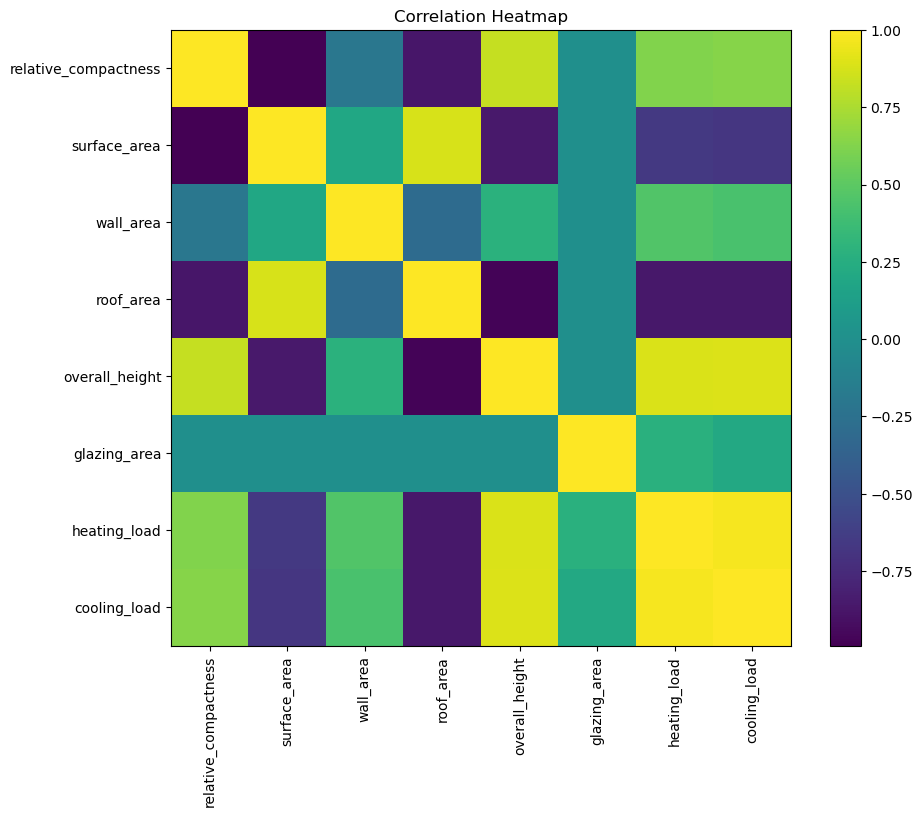

In [7]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

# EDA Findings

## Summary
- The dataset was loaded and inspected for shape, data types, duplicates, and missing values.
- Column names were cleaned and renamed to meaningful feature names.
- Categorical-coded columns such as `orientation` and `glazing_area_distribution` were converted to categorical type.
- Histograms and skewness checks were used to understand numeric distributions.
- Boxplots were used to detect possible outliers.
- Scatterplots were used to examine relationships between input features and both target variables.
- A correlation heatmap and high-correlation pair check were used to evaluate multicollinearity.